In [1]:
%load_ext autoreload

In [ ]:
import os
from unity_utils import UnityTranslator

dir = os.getcwd()
DATA_DIR = dir + '/data/transcript_6'
demos = UnityTranslator.get_from(DATA_DIR, dt=1)

FileNotFoundError: Video file not found: /Users/edward_kim/Desktop/narrated_demo/v2/data2/transcript_6/demonstration0/videos/participant0_demo0_segment0.mp4

In [3]:
demo = demos[0]

In [4]:
import json
from nlp_utils import *

inference_instructions = """
The user inputs a series of top-down keyframes (in chronological order) from a video where a soccer coach instructs on how to play under a particular scenario as if they were a player.
You're tasked to reason about the keyframes in the context of the coach's explanation and demonstrations and build a series of tasks for the player.
We would like to learn such behaviour from the coach for another player replacing them so tasks should be defined for the coach or hypothetical player replacing the coach.

Tasks are defined in the context of a finite state machine were each task denotes a node with a termination condition, i.e., the condition under which the task will be marked as terminated so the state can change,
and edges are preconditions, i.e., the condition under which a following task should be triggered and the state changes from the previous task.

You response return must be a json with format 

{
    'nodes': [
        {
            'id': int,  // Unique identifier for the task node
            'action': str,  // 'wait', 'move_to', 'pass'
            'info': str,  // Description of the action
            'termination': str,  // Condition under which the task terminates
            'keyframe': int  // Keyframe index where the task ends
        }
    ],
    "edges": [
        {
            'id': int,  // Unique identifier for the condition edge
            'from': int,  // ID of the previous node
            'to': int,  // ID of the next node
            'precondition': str  // Condition under which the transition happens
            'keyframe': int  // Keyframe index where the task ends
        }
    ]
}

Note that careful frame selection is important for accurate behavior learning (e.g. when we learn when to make a pass we want to learn from the frame where the pass was made and both players are at the expected locations).
The subtasks should be ordered chronologically too.
"""

entries = [
    Chat.Entry(role='system', text=inference_instructions),
    Chat.Entry(role='user', text=demo.language)
] + [Chat.Entry(role='user', text=f'Frame index: {idx}', im=get_im(im_dir)) for idx, im_dir in enumerate(demo.video.frame_dir)]


# TODO: Change to o1 for reasoning
chat = Chat(client, model='gpt-4o')
response = json.loads(chat(entries, json=True))
print('Inference done.')

Inference done.


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


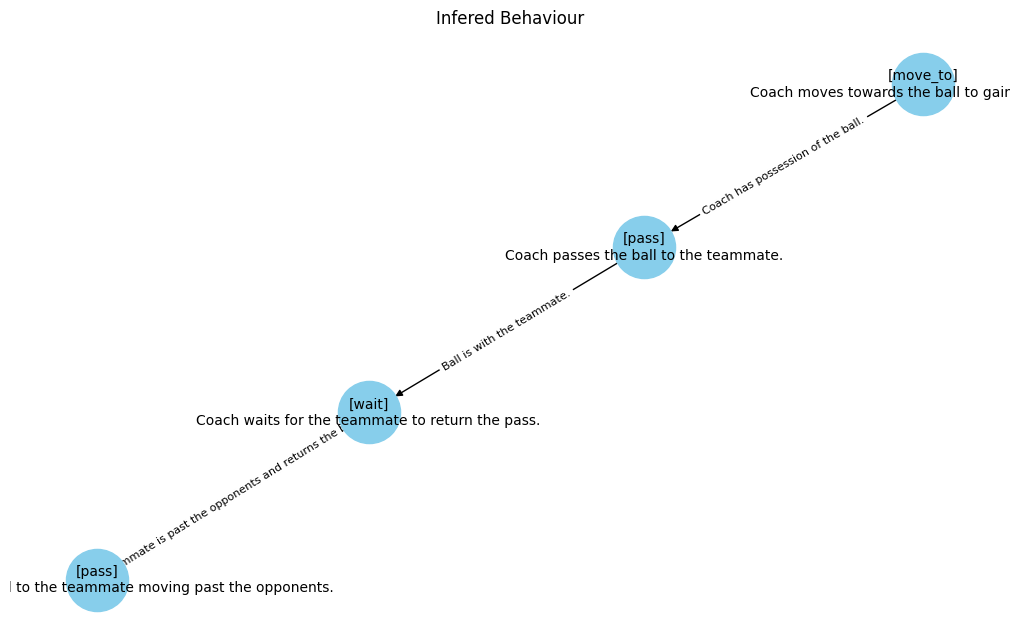

In [5]:
%load_ext autoreload
%autoreload 2

from synth_utils import Act
from scenic_fc.api import api

act = Act.from_dict(response, api)
act.show()

In [2]:
OUT_DIR = 'exports'

id = 'demo_1'
data = combined.to_dict(id=id, expanded=False)

os.makedirs(OUT_DIR, exist_ok=True)
with open(f'{OUT_DIR}/{id}.json', 'w') as f:
    json.dump(data, f, indent=4)

NameError: name 'combined' is not defined

In [7]:
act.nodes[0].termination.info

'Coach reaches the ball.'

In [8]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from PIL import Image

modifications = []
for i, t in enumerate(act.nodes):

    print(f'{i + 1}/{len(act.nodes)}')
    print()
    print(t)
    print('Termination:', t.termination.info)
    print('Infered keyframe:', t.t)
    
    plt.imshow(demo.video[demo.video.t_for(t.t[''])])
    plt.axis('off')
    plt.show()

    manual_keyframe = input('Type the index (0-indexed) of keyframe to modify it or return to continue.')
    if manual_keyframe != '' and int(manual_keyframe) < len(demo.video.frame_dir):
        t.keyframe = manual_keyframe
        modifications += [f'[Task {i + 1}] Modified keyframe: {t.original.keyframe} -> {t.keyframe}']

    clear_output(wait=False)

if not len(modifications):
    print('No modifications.')
for mod in modifications:
    print(mod)

No modifications.


In [9]:
%load_ext autoreload
%autoreload 2

from synth_utils import Synth

pipe = Synth(act, demo, api)
pipe.run()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
{'id': 'B', 'constraint': 'distance_to_object', 'args': {'fromObj': None, 'toObj': None, 'min': 0.0, 'max': 5.0, 'operator': 'less_than'}}


AttributeError: 'Constraint' object has no attribute 'learn'

In [ ]:
%load_ext autoreload
%autoreload 2

program = pipe.to_dict()
print(json.dumps(program, indent=4))

In [ ]:
%load_ext autoreload
%autoreload 2

from scenic_fc.constraints import DistanceToObject
from synth_utils import Constraint, Condition
from api_utils import API

API_REF = 'distance_to_object'
ARGS = {
    'toObj': 'teammate',
    'fromObj': 'coach'
}

condition = Condition()
condition.t = 2

constraint = Constraint('c1', condition, API_REF, ARGS, api[API.constraints])
constraint.synth(demo, api)